# Unsupervised Learning — Clustering & Regime-Based Error Analysis

**Predicting the Predictor: Regime-Based Error Analysis of BondDroid vs. TRACE**

This notebook clusters the prepared feature matrix into market/bond regimes, then analyzes how BondDroid's pricing error behaves across those regimes. The clustering features never see the error target, so any error differences across clusters are an emergent property of the regimes — not something we fit toward.

**Input:** `data/clustering/clustering_features.parquet` (produced by `SIADS 696 Unsupervised Prep.ipynb`):
- `*__z` — 10 RobustScaler-scaled features (the clustering matrix)
- `*__raw` — pre-scaling values (for interpretation)
- held-aside columns incl. `abs_price_error`, sector/region/segment labels (never clustered on)

### Pipeline
1. **Load** the scaled matrix.
2. **Model selection** — sweep K-Means `k` on a sample (elbow / silhouette / Davies–Bouldin).
3. **Fit** the final model on all 8.5M rows (`MiniBatchKMeans`), with **GMM** and **HDBSCAN** as robustness checks on a sample.
4. **Profile** each cluster — feature fingerprints + sector/region/segment composition.
5. **Error analysis** — BondDroid `abs_price_error` across clusters (the project payoff).
6. **Project** to 2D (UMAP) colored by cluster and by error.
7. **Persist** labeled rows, a cluster-profile table, and figures.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans, KMeans, HDBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

IN_PATH = "data/clustering/clustering_features.parquet"
OUT_DIR = "data/clustering"
FIG_DIR = "outputs/unsupervised"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

df = pd.read_parquet(IN_PATH)
FEATURES = [c for c in df.columns if c.endswith("__z")]
FEAT_NAMES = [c[:-3] for c in FEATURES]  # strip __z for labels
X = df[FEATURES].to_numpy(dtype=np.float32)

print(f"Rows: {X.shape[0]:,} | clustering features: {X.shape[1]}")
print("Features:", FEAT_NAMES)

Rows: 8,500,577 | clustering features: 10
Features: ['log_avg_daily_trades', 'log_volume', 'quote_age_seconds', 'bd_px_spread', 'oas_mid', 'DURATION_MID', 'COUPON', 'bd_mid_yield', 'hour_sin', 'hour_cos']


## 2. Choosing the number of clusters

With 8.5M rows, repeatedly fitting and scoring full models is wasteful, so we select `k` on a fixed random sample of 100k rows. We sweep `k = 2…10` and look at three complementary signals:

- **Inertia (elbow)** — within-cluster spread; look for the diminishing-returns bend.
- **Silhouette** (higher = better) — separation vs. cohesion.
- **Davies–Bouldin** (lower = better) — average cluster overlap.

No single metric is decisive for overlapping financial data, so we weigh them together and favor a `k` that is also interpretable as a set of market regimes.

k= 2 | inertia=      529288 | silhouette=0.566 | Davies-Bouldin=0.804 | Calinski-Harabasz=58,701


k= 3 | inertia=      422342 | silhouette=0.259 | Davies-Bouldin=1.390 | Calinski-Harabasz=49,443


k= 4 | inertia=      384644 | silhouette=0.251 | Davies-Bouldin=1.418 | Calinski-Harabasz=39,459


k= 5 | inertia=      354851 | silhouette=0.164 | Davies-Bouldin=1.637 | Calinski-Harabasz=34,178


k= 6 | inertia=      333611 | silhouette=0.136 | Davies-Bouldin=1.782 | Calinski-Harabasz=30,356


k= 7 | inertia=      317848 | silhouette=0.137 | Davies-Bouldin=1.732 | Calinski-Harabasz=27,377


k= 8 | inertia=      302952 | silhouette=0.140 | Davies-Bouldin=1.701 | Calinski-Harabasz=25,322


k= 9 | inertia=      290665 | silhouette=0.136 | Davies-Bouldin=1.690 | Calinski-Harabasz=23,622


k=10 | inertia=      279441 | silhouette=0.136 | Davies-Bouldin=1.683 | Calinski-Harabasz=22,286


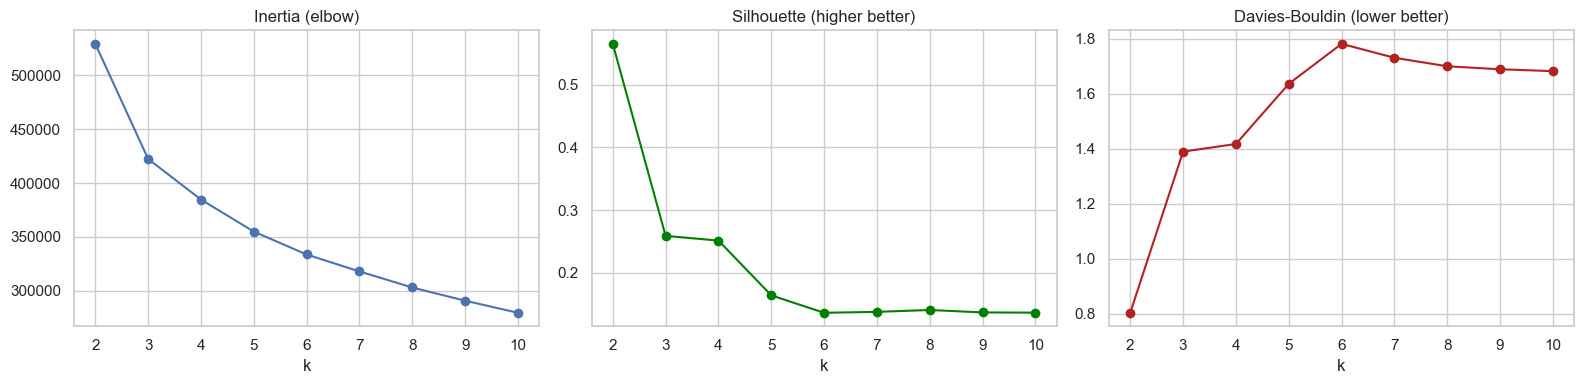

In [2]:
sample_idx = rng.choice(X.shape[0], size=min(100_000, X.shape[0]), replace=False)
Xs = X[sample_idx]

ks = list(range(2, 11))
inertia, sil, db, ch = [], [], [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    lab = km.fit_predict(Xs)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(Xs, lab, sample_size=20_000, random_state=RANDOM_STATE))
    db.append(davies_bouldin_score(Xs, lab))
    ch.append(calinski_harabasz_score(Xs, lab))
    print(f"k={k:2d} | inertia={km.inertia_:12.0f} | silhouette={sil[-1]:.3f} "
          f"| Davies-Bouldin={db[-1]:.3f} | Calinski-Harabasz={ch[-1]:,.0f}")

fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].plot(ks, inertia, "o-"); ax[0].set_title("Inertia (elbow)"); ax[0].set_xlabel("k")
ax[1].plot(ks, sil, "o-", color="green"); ax[1].set_title("Silhouette (higher better)"); ax[1].set_xlabel("k")
ax[2].plot(ks, db, "o-", color="firebrick"); ax[2].set_title("Davies-Bouldin (lower better)"); ax[2].set_xlabel("k")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/kmeans_model_selection.png", dpi=120); plt.show()

### Decision: `k = 4`

Silhouette is maximized at `k=2`, but that is too coarse to study error regimes. The inertia elbow flattens around `k=3–4`, and inspecting the cluster centers shows `k=4` yields four economically distinct regimes (no micro-clusters), whereas `k=5` mostly carves out a time-of-day split (`hour_sin/hour_cos`) that isn't a meaningful market regime. We therefore use **`k = 4`** as the primary segmentation and validate its stability with GMM and HDBSCAN below.

We fit the final model with **`MiniBatchKMeans`** so it scales to all 8.5M rows (full `KMeans` would be unnecessarily slow at this size).

In [3]:
FINAL_K = 4

kmeans = MiniBatchKMeans(n_clusters=FINAL_K, random_state=RANDOM_STATE,
                         n_init=10, batch_size=10_000)
df["cluster"] = kmeans.fit_predict(X)

sizes = df["cluster"].value_counts().sort_index()
print(f"MiniBatchKMeans (k={FINAL_K}) fit on {X.shape[0]:,} rows\n")
print("Cluster sizes:")
for c, n in sizes.items():
    print(f"  cluster {c}: {n:>10,} ({n/len(df)*100:5.1f}%)")

# Scaled cluster centers (the regime fingerprints)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=FEAT_NAMES).round(2)
centers.index.name = "cluster"
print("\nScaled cluster centers:")
print(centers.to_string())

MiniBatchKMeans (k=4) fit on 8,500,577 rows

Cluster sizes:
  cluster 0:  4,792,826 ( 56.4%)
  cluster 1:    492,820 (  5.8%)
  cluster 2:  1,155,613 ( 13.6%)
  cluster 3:  2,059,318 ( 24.2%)

Scaled cluster centers:
         log_avg_daily_trades  log_volume  quote_age_seconds  bd_px_spread  oas_mid  DURATION_MID  COUPON  bd_mid_yield  hour_sin  hour_cos
cluster                                                                                                                                    
0                        0.23        0.00              -0.07         -0.20    -0.34         -0.20   -0.36         -0.35      0.10      0.16
1                        0.10       -0.08              -0.02          2.89     5.59          0.19    1.09          4.01      0.34      0.18
2                       -0.36        0.40              -0.14          1.51     0.44          1.96    0.18          0.39      0.10      0.36
3                        0.00        0.06              -0.04          0.50     0.88

## 3. Robustness checks — GMM and HDBSCAN

K-Means imposes spherical, equal-variance clusters. We sanity-check the `k=4` structure two ways on a sample:

- **Gaussian Mixture (GMM)** — allows elliptical clusters; we also report BIC across `k` and the **Adjusted Rand Index (ARI)** between GMM and K-Means labels (high ARI = the partition is not an artifact of the spherical assumption).
- **HDBSCAN** — density-based, finds clusters of arbitrary shape and labels low-density points as noise. We report how many dense clusters it finds and the noise fraction.

In [4]:
from sklearn.metrics import adjusted_rand_score

# Reuse a 100k sample for the (more expensive) GMM / HDBSCAN checks
chk_idx = rng.choice(X.shape[0], size=100_000, replace=False)
Xc = X[chk_idx]
km_lab_chk = kmeans.predict(Xc)

# --- GMM: BIC sweep + agreement with K-Means at k=4 ---
print("GMM BIC by k (lower is better):")
for k in range(2, 9):
    g = GaussianMixture(n_components=k, covariance_type="full",
                        random_state=RANDOM_STATE, n_init=1)
    g.fit(Xc)
    print(f"  k={k}: BIC={g.bic(Xc):,.0f}")

gmm = GaussianMixture(n_components=FINAL_K, covariance_type="full",
                      random_state=RANDOM_STATE, n_init=1).fit(Xc)
gmm_lab = gmm.predict(Xc)
print(f"\nARI(K-Means, GMM) at k={FINAL_K}: {adjusted_rand_score(km_lab_chk, gmm_lab):.3f}")

# --- HDBSCAN: density view (subsample for tractability) ---
hdb_idx = rng.choice(X.shape[0], size=50_000, replace=False)
Xh = X[hdb_idx]
hdb = HDBSCAN(min_cluster_size=500, min_samples=25)
hdb_lab = hdb.fit_predict(Xh)
n_clusters = len(set(hdb_lab)) - (1 if -1 in hdb_lab else 0)
noise = float(np.mean(hdb_lab == -1))
print(f"\nHDBSCAN: {n_clusters} dense clusters | noise fraction = {noise:.1%}")
km_lab_h = kmeans.predict(Xh)
mask = hdb_lab != -1
if mask.sum() > 0:
    print(f"ARI(K-Means, HDBSCAN) on non-noise points: "
          f"{adjusted_rand_score(km_lab_h[mask], hdb_lab[mask]):.3f}")

GMM BIC by k (lower is better):


  k=2: BIC=1,685,035


  k=3: BIC=1,593,889


  k=4: BIC=1,471,910


  k=5: BIC=1,446,996


...

  k=7: BIC=1,257,391


  k=8: BIC=1,244,617



ARI(K-Means, GMM) at k=4: 0.390


/Users/saint.gau/Documents/GitHub/SIADS-696-Bond-Analysis/venv/lib/python3.14/site-packages/sklearn/cluster/_hdbscan/hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(



HDBSCAN: 2 dense clusters | noise fraction = 11.4%
ARI(K-Means, HDBSCAN) on non-noise points: 0.039


## 4. Cluster profiles — what each regime *is*

We describe each cluster in interpretable units using the `*__raw` columns, plus its dominant sector / region / market segment and snapshot share. The heatmap shows the scaled center of each feature per cluster.

Cluster profiles (medians in raw units):
         share_%        n  log_avg_daily_trades  log_volume  quote_age_seconds  bd_px_spread  oas_mid  DURATION_MID  COUPON  bd_mid_yield  hour_sin  hour_cos                                     top_sector                   top_region   top_segment  snapshot_%  ttm_years_med
cluster                                                                                                                                                                                                                                                                           
0           56.4  4792826                 3.128       9.904             1884.0         0.056   59.549         3.169   0.037         0.049    -0.259    -0.866                                  Manufacturing                North America  DM Corporate        95.4            3.5
1            5.8   492820                 2.940       9.999             1977.0         0.549  433.141         4.398   0.065         0.

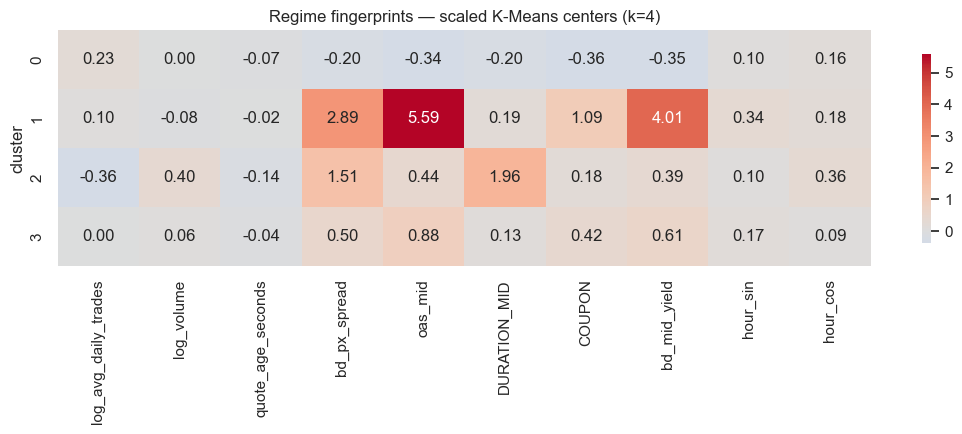

In [ ]:
raw_cols = [c for c in df.columns if c.endswith("__raw")]
raw_names = [c[:-5] for c in raw_cols]

# Median of each raw feature per cluster (median = robust to remaining tails)
prof = df.groupby("cluster")[raw_cols].median()
prof.columns = raw_names
prof.insert(0, "share_%", (df["cluster"].value_counts(normalize=True).sort_index() * 100).round(1))
prof.insert(1, "n", df["cluster"].value_counts().sort_index())

# Dominant categorical labels + snapshot share per cluster
def top_cat(col):
    return df.groupby("cluster")[col].agg(lambda s: s.value_counts().idxmax())
prof["top_sector"] = top_cat("BONDDROID_SECTOR")
prof["top_region"] = top_cat("REGION")
prof["top_segment"] = top_cat("MARKET_SEGMENT")
prof["snapshot_%"] = (df.groupby("cluster")["is_snapshot"].mean() * 100).round(1)
prof["ttm_years_med"] = df.groupby("cluster")["ttm_years"].median().round(1)

print("Cluster profiles (medians in raw units):")
print(prof.round(3).to_string())

# Regime fingerprint heatmap (scaled centers)
fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(centers, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            cbar_kws={"shrink": .8}, ax=ax)
ax.set_title(f"Scaled K-Means centers (k={FINAL_K})")
ax.set_ylabel("cluster")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/cluster_fingerprints.png", dpi=120); plt.show()

## 5. BondDroid error across regimes — the payoff

`abs_price_error = |bd_mid_px − trace_price|` was held out of clustering. If it differs systematically across regimes, then BondDroid's accuracy is regime-dependent. We also compute a price-relative error (`abs_price_error / trace_price × 100`, in % of price) so large-dollar-price bonds don't dominate, and run a Kruskal–Wallis test for whether the error distributions differ across clusters.

BondDroid error by regime:
               n  abs_err_mean  abs_err_median  abs_err_p90  rel_err_median  rel_err_p90
cluster                                                                                 
0        4792826        0.2380          0.1164       0.5059          0.1213       0.5340
1         492820        0.8182          0.5040       1.7284          0.5732       1.9985
2        1155613        0.7484          0.3890       1.5937          0.4513       1.8257
3        2059318        0.4171          0.2326       1.0009          0.2385       1.0103

Overall median abs error: 0.1721
Median abs error relative to overall, by cluster:
cluster
0    0.68
1    2.93
2    2.26
3    1.35



Kruskal-Wallis across clusters: H=1,208,463, p=0.000e+00


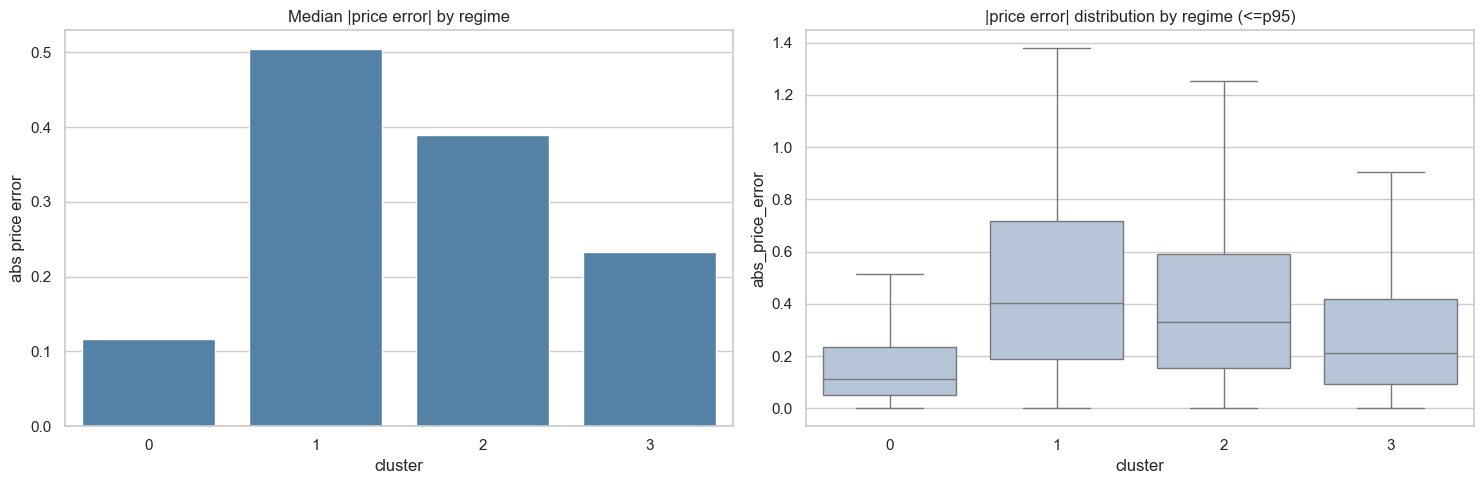

In [6]:
from scipy.stats import kruskal

df["rel_error_pct"] = (df["abs_price_error"] / df["trace_price"].abs()) * 100.0

err = df.groupby("cluster").agg(
    n=("abs_price_error", "size"),
    abs_err_mean=("abs_price_error", "mean"),
    abs_err_median=("abs_price_error", "median"),
    abs_err_p90=("abs_price_error", lambda s: s.quantile(0.90)),
    rel_err_median=("rel_error_pct", "median"),
    rel_err_p90=("rel_error_pct", lambda s: s.quantile(0.90)),
).round(4)
print("BondDroid error by regime:")
print(err.to_string())

overall = df["abs_price_error"].median()
print(f"\nOverall median abs error: {overall:.4f}")
print("Median abs error relative to overall, by cluster:")
print((df.groupby("cluster")["abs_price_error"].median() / overall).round(2).to_string())

# Kruskal-Wallis: do error distributions differ across clusters?
groups = [g["abs_price_error"].values for _, g in df.groupby("cluster")]
H, p = kruskal(*groups)
print(f"\nKruskal-Wallis across clusters: H={H:,.0f}, p={p:.3e}")

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=err.index, y=err["abs_err_median"], ax=ax[0], color="steelblue")
ax[0].set_title("Median |price error| by regime"); ax[0].set_xlabel("cluster"); ax[0].set_ylabel("abs price error")
# clipped box for shape (drop the extreme tail so boxes are readable)
cap = df["abs_price_error"].quantile(0.95)
sub = df[df["abs_price_error"] <= cap]
sns.boxplot(data=sub, x="cluster", y="abs_price_error", ax=ax[1], showfliers=False, color="lightsteelblue")
ax[1].set_title("|price error| distribution by regime (<=p95)"); ax[1].set_xlabel("cluster")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/error_by_cluster.png", dpi=120); plt.show()

## 6. 2D projection

UMAP embedding of a 50k sample, colored by (a) cluster and (b) log price error. This is a visual aid only — the clustering was done in the full 10-D space, not on the projection. If high-error points concentrate in particular regions/regimes, that reinforces the error-by-regime result.

/Users/saint.gau/Documents/GitHub/SIADS-696-Bond-Analysis/venv/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


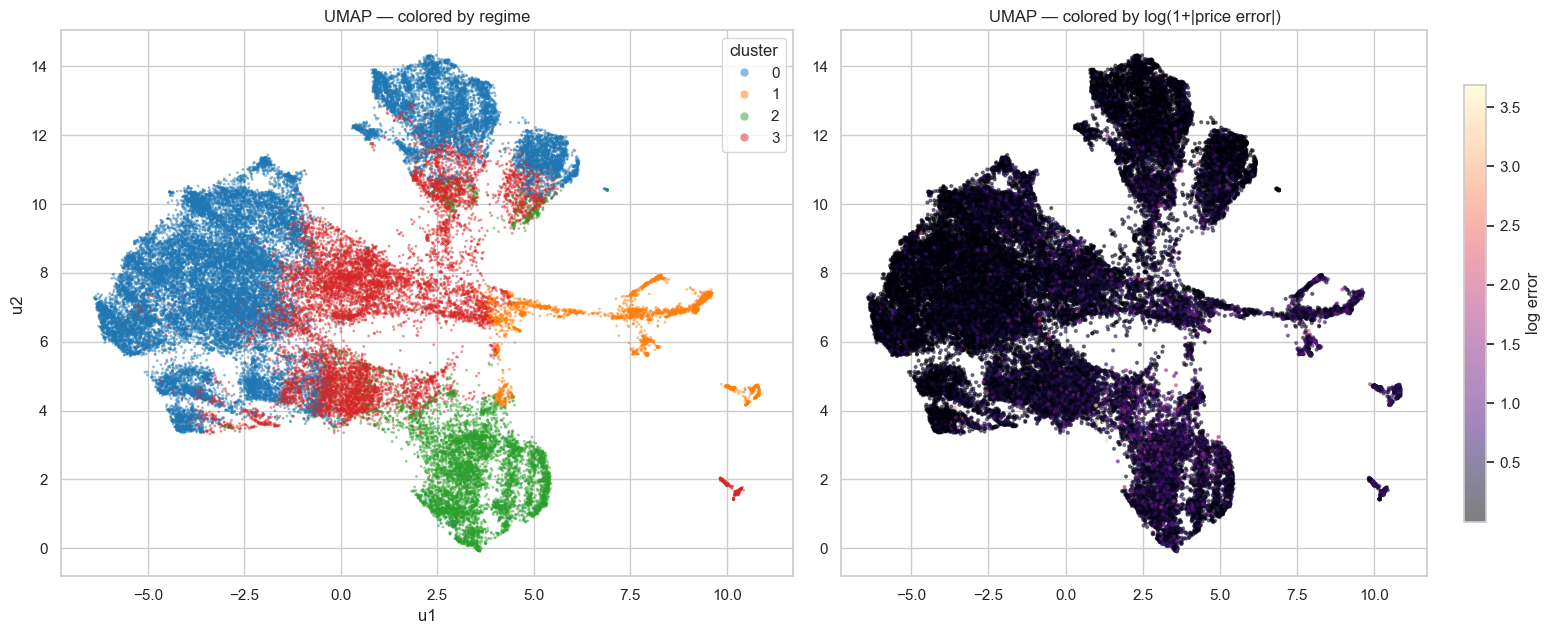

In [7]:
import umap

emb_idx = rng.choice(X.shape[0], size=50_000, replace=False)
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=RANDOM_STATE)
emb = reducer.fit_transform(X[emb_idx])

emb_df = pd.DataFrame(emb, columns=["u1", "u2"])
emb_df["cluster"] = df["cluster"].to_numpy()[emb_idx]
emb_df["log_err"] = np.log1p(df["abs_price_error"].to_numpy()[emb_idx])

fig, ax = plt.subplots(1, 2, figsize=(16, 6.5))
sns.scatterplot(data=emb_df, x="u1", y="u2", hue="cluster", palette="tab10",
                s=4, linewidth=0, alpha=0.5, ax=ax[0])
ax[0].set_title("UMAP — colored by regime"); ax[0].legend(title="cluster", markerscale=3)
sc = ax[1].scatter(emb_df["u1"], emb_df["u2"], c=emb_df["log_err"], cmap="magma", s=4, alpha=0.5)
ax[1].set_title("UMAP — colored by log(1+|price error|)")
plt.colorbar(sc, ax=ax[1], shrink=0.8, label="log error")
plt.tight_layout(); plt.savefig(f"{FIG_DIR}/umap_clusters_error.png", dpi=120); plt.show()

## 7. Save results

- `data/clustering/clustering_labeled.parquet` — every row with its `cluster` label, identifiers, raw features, error columns, and categorical labels (the artifact for downstream analysis / the report).
- `data/clustering/cluster_profile.csv` — the per-regime summary table.
- Figures in `outputs/unsupervised/`.

In [8]:
keep = (["cluster", "cusip", "FIGI", "bd_ts", "trade_ts",
         "abs_price_error", "rel_error_pct", "trace_price", "bd_mid_px",
         "BONDDROID_SECTOR", "BONDDROID_INDUSTRY", "REGION", "MARKET_SEGMENT",
         "TRIGGER_TYPE", "is_snapshot", "ttm_years"]
        + raw_cols)

labeled_path = f"{OUT_DIR}/clustering_labeled.parquet"
df[keep].to_parquet(labeled_path, index=False)

profile_path = f"{OUT_DIR}/cluster_profile.csv"
prof.to_csv(profile_path)

print(f"Saved: {labeled_path}  ({len(df):,} rows x {len(keep)} cols)")
print(f"Saved: {profile_path}")
print(f"Figures in {FIG_DIR}/:")
for f in ["kmeans_model_selection.png", "cluster_fingerprints.png",
          "error_by_cluster.png", "umap_clusters_error.png"]:
    print(f"  {f}")
print(f"\nFinal segmentation: K-Means k={FINAL_K} on {len(df):,} trades.")

Saved: data/clustering/clustering_labeled.parquet  (8,500,577 rows x 26 cols)
Saved: data/clustering/cluster_profile.csv
Figures in outputs/unsupervised/:
  kmeans_model_selection.png
  cluster_fingerprints.png
  error_by_cluster.png
  umap_clusters_error.png

Final segmentation: K-Means k=4 on 8,500,577 trades.


## 8. Findings

**The four regimes (k = 4):**

| Cluster | Share | Regime | Fingerprint (raw medians) |
|---|---|---|---|
| **0** | 56.4% | **Liquid IG core** | Low OAS (~60 bps), low spread, short duration (~3.5y), DM Corporate / North America. The "standard" majority. |
| **1** | 5.8% | **Distressed / EM high-yield** | Extreme OAS (~433 bps), wide bid-ask, high coupon & yield; Mining/Oil & Gas, EM Corporate, Latin America. |
| **2** | 13.6% | **Long-duration / rate-sensitive** | Very high duration (~24.5y TTM, duration ~13), larger trade size, moderate OAS. |
| **3** | 24.2% | **Moderate-spread mid-tier** | Mid OAS (~125 bps), mid duration (~6y) — bridge between core and stressed regimes. |

**BondDroid error is strongly regime-dependent**. Versus the overall median absolute price error:

- **Cluster 0 (liquid IG core): 0.68×** — BondDroid is most accurate here.
- **Cluster 3 (mid-tier): 1.35×**
- **Cluster 2 (long-duration): 2.26×**
- **Cluster 1 (distressed/EM HY): 2.93×** — BondDroid struggles most here.

Error rises with credit spread, duration, and illiquidity. Kruskal–Wallis across clusters: H ≈ 1.2M, p ≈ 0 — the error distributions are overwhelmingly different by regime. The same ordering holds for price-relative error, so it isn't just a result of dollar price.

**Robustness / honest caveats.** GMM at k=4 agrees moderately with K-Means (ARI ≈ 0.39) and HDBSCAN finds only ~2 dense cores with ~11% noise (ARI ≈ 0.04). Together with the declining silhouette, this indicates the bond cross-section is closer to a continuum than a set of well-separated natural clusters. Therefore, `k=4` is as a useful, interpretable snapshot of that continuum for error analysis. The error-by-regime signal is robust to that caveat: it tracks the underlying continuous axes (spread / duration / liquidity) regardless of exact cluster boundaries.